In [58]:
# Load peristim matrix
import numpy as np
from pathlib import Path
import RCP_analysis as rcp

%matplotlib inline
import matplotlib.pyplot as plt

# Paths
REPO_ROOT = Path().resolve().parents[1]
PARAMS = rcp.load_experiment_params(REPO_ROOT / "config" / "params.yaml", repo_root=REPO_ROOT)

SESSION_LOC = (Path(PARAMS.data_root) / Path(PARAMS.location)).resolve()
OUT_BASE = SESSION_LOC / "results"
OUT_BASE.mkdir(parents=True, exist_ok=True)
UA_CKPT_OUT = OUT_BASE / "checkpoints" / "UA"
METADATA_ROOT = SESSION_LOC / "Metadata"
METADATA_CSV   = METADATA_ROOT / f"{PARAMS.session}_metadata.csv"

XLS = rcp.ua_excel_path(REPO_ROOT, PARAMS.probes)
UA_MAP = rcp.load_UA_mapping_from_excel(XLS) if XLS else None
if UA_MAP is None:
    raise RuntimeError("UA mapping required for mapping on NS6.")

SESS = SESSION_LOC / "Blackrock" / "Nike_UA_S3_001"

In [61]:
import spikeinterface as si
import spikeinterface.preprocessing as spre
import spikeinterface.extractors as se

rec_ns6 = se.read_blackrock(SESS, stream_name = 'nsx6', all_annotations=True) # Load neural data
br_idx = int(SESS.name.split('_')[-1])

rec_ns6, idx_rows, ua_elec, ua_nsp, ua_region, ua_region_names, ua_port = rcp.apply_ua_mapping_with_regions(rec_ns6, UA_MAP, br_idx, METADATA_CSV)
UA_probe = ua_region.copy()

rec_hp  = spre.highpass_filter(rec_ns6, freq_min=float(PARAMS.highpass_hz))
region_idx, elec_count = np.unique(UA_probe, return_counts=True)
print(" | ".join(f"{ua_region_names[v]}: {c}" for v, c in zip(region_idx, elec_count)))

[MAP] UA port from metadata: 'A'
[MAP] renamed 128/128 rows with UA mapping ('UAe###_NSP###') using port 'A'.
SMA: 30 | Dorsal premotor: 32 | M1 inferior: 31 | M1 superior: 35


In [62]:
import spikeinterface as si
fs_ua = float(rec_hp.get_sampling_frequency())

print(rec_hp)
print(f"Sampling rate: {fs_ua:.1f} Hz")
print(f"Num channels: {rec_hp.get_num_channels()}")
print(f"Duration: {rec_hp.get_num_frames() / fs_ua:.1f} s")

HighpassFilterRecording: 128 channels - 30.0kHz - 1 segments - 44,936,631 samples 
                         1,497.89s (24.96 minutes) - int16 dtype - 10.71 GiB
Sampling rate: 30000.0 Hz
Num channels: 128
Duration: 1497.9 s


In [63]:
rec_hp

HighpassFilterRecording: 128 channels - 30.0kHz - 1 segments - 44,936,631 samples 
                         1,497.89s (24.96 minutes) - int16 dtype - 10.71 GiB

In [66]:
rec_hp_slice = rec_hp.frame_slice(0, 60*30000)

In [67]:
rec_hp_slice

FrameSliceRecording: 128 channels - 30.0kHz - 1 segments - 1,800,000 samples 
                     60.00s (1.00 minutes) - int16 dtype - 439.45 MiB

In [68]:
from spikeinterface.sortingcomponents.peak_detection import detect_peaks

ua_noise_levels = si.get_noise_levels(rec_hp_slice, method="mad", return_in_uV=False) # They didn't write return_in_uV in their documentation
ua_peak_idx = detect_peaks(
    rec_hp_slice,
    method="by_channel",
    detect_threshold=3,
    peak_sign='both',
    noise_levels=ua_noise_levels,
    n_jobs=2,
)

noise_level (no parallelization):   0%|          | 0/20 [00:00<?, ?it/s]

detect peaks using by_channel (workers: 2 processes):   0%|          | 0/60 [00:00<?, ?it/s]

In [69]:
def _parse_SI_peaks(peaks) -> tuple[dict[int, np.ndarray], dict[int, np.ndarray]]:
    peak_times = {}
    peak_amp = {}
    for i in np.unique(peaks['channel_index']):
        peak_ch_times = peaks['sample_index'][peaks['channel_index'] == i]
        peak_ch_amp = peaks['amplitude'][peaks['channel_index'] == i]
        peak_times[i] = peak_ch_times
        peak_amp[i] = peak_ch_amp
    return peak_times, peak_amp

# ua_peaks_si_obj = np.load(ua_peaks_folder, allow_pickle=True)
ua_peak_samps, ua_peak_amps = _parse_SI_peaks(ua_peak_idx)
ua_peak_ms   = {k: (v / 30000)   * 1000.0 for k, v in ua_peak_samps.items()}

In [70]:
ua_peak_amps

{np.int64(0): array([ 88.,  87., 103., ...,  95., 107.,  87.], shape=(5111,)),
 np.int64(1): array([ 103., -125.,  -90., ...,  112.,   87.,  -87.], shape=(7378,)),
 np.int64(2): array([ 105., -172., -128., ..., -108.,  150., -108.], shape=(10021,)),
 np.int64(3): array([ 74., -79., -85., ...,  76., -80., -92.], shape=(5627,)),
 np.int64(4): array([ -87.,  -92.,  101., ..., -102.,   97.,  103.], shape=(6595,)),
 np.int64(5): array([-56., -77.,  56., ..., -68., -66.,  55.], shape=(5352,)),
 np.int64(6): array([ -90., -121.,  112., ...,  -84.,  -82.,  -80.], shape=(6030,)),
 np.int64(7): array([ 74., -69., -68., ...,  69., -79.,  72.], shape=(5126,)),
 np.int64(8): array([-106., -102., -116., ..., -138., -102., -140.], shape=(7244,)),
 np.int64(9): array([ -72.,   72.,  -66., ...,   68., -108.,  -81.], shape=(5114,)),
 np.int64(10): array([ 87.,  72.,  76., ..., -77.,  73.,  72.], shape=(5115,)),
 np.int64(11): array([-57.,  53.,  54., ..., -56.,  63., -62.], shape=(4953,)),
 np.int64(12)

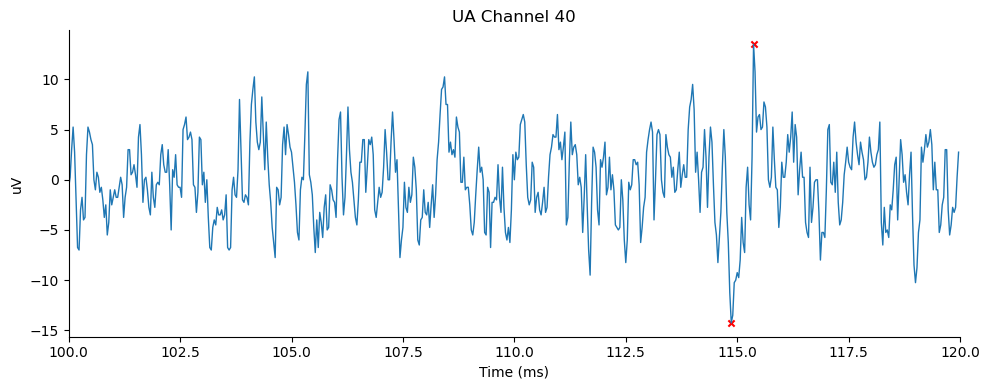

In [71]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

CH = 39
T0_MS, T1_MS = 100, 120
PLOT_SHIFT = 0

fs = fs_ua
rec = rec_hp

i0 = int(T0_MS * fs / 1000.0)
i1 = int(T1_MS * fs / 1000.0)

ch_id = rec.get_channel_ids()[CH]
y = rec.get_traces(start_frame=i0, end_frame=i1, channel_ids=[ch_id], return_in_uV=True).squeeze()
t = (np.arange(i0, i1) / fs) * 1000.0

peak_s = np.asarray(ua_peak_samps.get(CH, []), dtype=np.int64)

m = (peak_s >= i0) & (peak_s < i1)
peak_s_ch = peak_s[m]

peak_idx = (peak_s_ch - i0).astype(int)
peak_ms_ch = (peak_s_ch / fs) * 1000.0
peak_amps_ch = y[peak_idx]

plt.figure(figsize=(10, 4))
plt.plot(t, y, lw=1)

if peak_ms_ch.size:
    plt.scatter(peak_ms_ch + PLOT_SHIFT / 30.0, peak_amps_ch, s=20, marker="x", color="red")

plt.xlim(T0_MS, T1_MS)
plt.xlabel("Time (ms)")
plt.ylabel("uV")
plt.title(f"UA Channel {CH+1}")
plt.gca().spines[["right", "top"]].set_visible(False)
plt.tight_layout()
plt.show()

In [72]:
peak_s

array([   2809,    2926,    3446, ..., 1799275, 1799355, 1799405],
      shape=(6108,))